# Load data from InfluxDB

In [38]:
%pip install influxdb-client


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [39]:
from datetime import datetime, timezone
from influxdb_client import InfluxDBClient, Point, WritePrecision
from influxdb_client.client.write_api import SYNCHRONOUS
from random import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Replace these with your InfluxDB token, organization, and bucket
org = "ur3e"
bucket = "ur3e"
token = "-BZITnY_s_YijW3jrGyzuOgiQxxMtXEU9U_yxpBLYlUiPZw0kKvethzTBR2A4NqZuVVw-2bKQ70rDUuPgNCQJQ=="

# Initialize the client
client = InfluxDBClient(url="http://localhost:8086", token=token, org=org)
write_api = client.write_api(write_options=SYNCHRONOUS)   
query_api = client.query_api()

In [40]:
# 1. Define the dynamic variables in the params dictionary
time_start = "-24h"
time_stop = "now()"
window = "1s"

# 2. Define the query using the v.variable syntax
query_sensor_data = f'''
from(bucket: "ur3e")
  |> range(start: {time_start}, stop: {time_stop})
  |> filter(fn: (r) => r["_measurement"] == "sensor_data")
  |> filter(fn: (r) => r["_field"] =~ /(q|qd)_actual_joint_[0-5]/)
  |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")
'''

query_ctrl_msgs = f'''
from(bucket: "ur3e")
  |> range(start: {time_start}, stop: {time_stop})
  |> filter(fn: (r) => r["_measurement"] == "ctrl_msgs")
  |> filter(fn: (r) => r["_field"] == "msg_type")
  |> filter(fn: (r) => r["msg_type"] == "play")
'''

# 3. Execute and return as a DataFrame
df_sensor_data = query_api.query_data_frame(query_sensor_data)
df_ctrl_msgs = query_api.query_data_frame(query_ctrl_msgs)




/home/losmobilos3/Desktop/Engineering Digital Twins/UR3eDTCourse/.venv/lib/python3.11/site-packages/influxdb_client/client/warnings.py:31: MissingPivotFunction: The query doesn't contains the pivot() function.

The result will not be shaped to optimal processing by pandas.DataFrame. Use the pivot() function by:

    
from(bucket: "ur3e")
  |> range(start: -24h, stop: now())
  |> filter(fn: (r) => r["_measurement"] == "ctrl_msgs")
  |> filter(fn: (r) => r["_field"] == "msg_type")
  |> filter(fn: (r) => r["msg_type"] == "play")
 |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")

You can disable this warning by:
    import warnings
    from influxdb_client.client.warnings import MissingPivotFunction

    warnings.simplefilter("ignore", MissingPivotFunction)

For more info see:
    - https://docs.influxdata.com/resources/videos/pivots-in-flux/
    - https://docs.influxdata.com/flux/latest/stdlib/universe/pivot/
    - https://docs.influxdata.com/flux/latest/stdlib/inf

# Show data

In [41]:
print(df_ctrl_msgs.head())

    result  table                           _start  \
0  _result      0 2026-03-16 10:51:06.371764+00:00   
1  _result      0 2026-03-16 10:51:06.371764+00:00   
2  _result      0 2026-03-16 10:51:06.371764+00:00   
3  _result      0 2026-03-16 10:51:06.371764+00:00   
4  _result      0 2026-03-16 10:51:06.371764+00:00   

                             _stop                            _time _value  \
0 2026-03-17 10:51:06.371764+00:00 2026-03-17 10:26:18.834355+00:00   play   
1 2026-03-17 10:51:06.371764+00:00 2026-03-17 10:27:58.829609+00:00   play   
2 2026-03-17 10:51:06.371764+00:00 2026-03-17 10:29:38.831772+00:00   play   
3 2026-03-17 10:51:06.371764+00:00 2026-03-17 10:31:18.833505+00:00   play   
4 2026-03-17 10:51:06.371764+00:00 2026-03-17 10:32:58.835176+00:00   play   

     _field _measurement msg_type                 source  
0  msg_type    ctrl_msgs     play  data_recorder_service  
1  msg_type    ctrl_msgs     play  data_recorder_service  
2  msg_type    ctrl_msgs     

In [42]:
print(df_sensor_data.head())


    result  table                            _time  \
0  _result      0 2026-03-17 10:25:57.156264+00:00   
1  _result      0 2026-03-17 10:25:57.205907+00:00   
2  _result      0 2026-03-17 10:25:57.255828+00:00   
3  _result      0 2026-03-17 10:25:57.304806+00:00   
4  _result      0 2026-03-17 10:25:57.354614+00:00   

                            _start                            _stop  \
0 2026-03-16 10:51:05.922725+00:00 2026-03-17 10:51:05.922725+00:00   
1 2026-03-16 10:51:05.922725+00:00 2026-03-17 10:51:05.922725+00:00   
2 2026-03-16 10:51:05.922725+00:00 2026-03-17 10:51:05.922725+00:00   
3 2026-03-16 10:51:05.922725+00:00 2026-03-17 10:51:05.922725+00:00   
4 2026-03-16 10:51:05.922725+00:00 2026-03-17 10:51:05.922725+00:00   

  _measurement                 source  q_actual_joint_0  q_actual_joint_1  \
0  sensor_data  data_recorder_service     -7.869745e-08             -1.57   
1  sensor_data  data_recorder_service     -6.004316e-09             -1.57   
2  sensor_data  d

In [43]:
sensor_data_np = df_sensor_data.to_numpy()
start_msgs_timestamps = df_ctrl_msgs["_time"].to_list()

In [44]:
sensor_data_np.shape

(30055, 19)

In [45]:
sensor_data_np[0, :]

array(['_result', 0,
       Timestamp('2026-03-17 10:25:57.156264+0000', tz='UTC'),
       Timestamp('2026-03-16 10:51:05.922725+0000', tz='UTC'),
       Timestamp('2026-03-17 10:51:05.922725+0000', tz='UTC'),
       'sensor_data', 'data_recorder_service', -7.869744661578132e-08,
       -1.570000022745029, 1.570000180758667, -1.5699999561369649,
       -1.5700000002426153, 3.470370523656083e-08, 0.0, 0.0, 0.0, 0.0,
       0.0, 0.0], dtype=object)

In [46]:
start_msgs_timestamps

[Timestamp('2026-03-17 10:26:18.834355+0000', tz='UTC'),
 Timestamp('2026-03-17 10:27:58.829609+0000', tz='UTC'),
 Timestamp('2026-03-17 10:29:38.831772+0000', tz='UTC'),
 Timestamp('2026-03-17 10:31:18.833505+0000', tz='UTC'),
 Timestamp('2026-03-17 10:32:58.835176+0000', tz='UTC'),
 Timestamp('2026-03-17 10:34:38.839577+0000', tz='UTC'),
 Timestamp('2026-03-17 10:36:18.840639+0000', tz='UTC'),
 Timestamp('2026-03-17 10:37:58.843422+0000', tz='UTC'),
 Timestamp('2026-03-17 10:39:38.847001+0000', tz='UTC'),
 Timestamp('2026-03-17 10:41:18.847638+0000', tz='UTC'),
 Timestamp('2026-03-17 10:42:58.852316+0000', tz='UTC'),
 Timestamp('2026-03-17 10:44:38.855299+0000', tz='UTC'),
 Timestamp('2026-03-17 10:46:18.856437+0000', tz='UTC'),
 Timestamp('2026-03-17 10:47:58.857226+0000', tz='UTC'),
 Timestamp('2026-03-17 10:49:38.861492+0000', tz='UTC')]

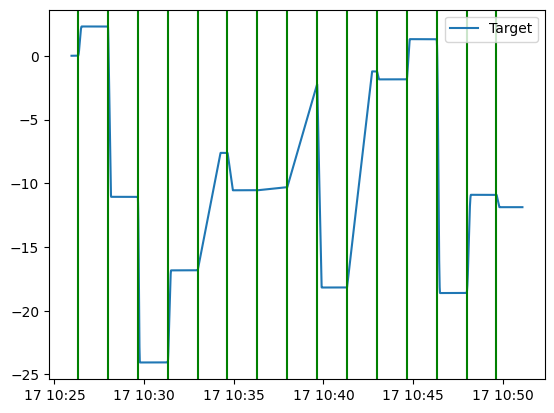

In [47]:
lower_bound = 0
upper_bound = -1

plt.plot(sensor_data_np[lower_bound:upper_bound, 2], sensor_data_np[lower_bound:upper_bound, -7], label="Target")
for movement_start in start_msgs_timestamps:
    plt.axvline(movement_start, color="g")

plt.legend()

# Determine end of movements
From observing the PT mockup, we have determined that all joints take the same amount of time to move.

In [48]:
import copy
# Translate timestamps into indexes
start_indexes = []
start_timestamps = copy.deepcopy(start_msgs_timestamps)

for n in range(sensor_data_np.shape[0] - 1):
    time_at_n = sensor_data_np[n, 2]
    time_at_n_plus_1 = sensor_data_np[n+1, 2]
    if time_at_n <= start_timestamps[0] <= time_at_n_plus_1:
        start_indexes.append(n)
        start_timestamps.pop(0)
    if len(start_timestamps) == 0:
        break

In [49]:
start_indexes

[431,
 2424,
 4415,
 6407,
 8400,
 10390,
 12382,
 14374,
 16368,
 18361,
 20353,
 22345,
 24336,
 26329,
 28320]

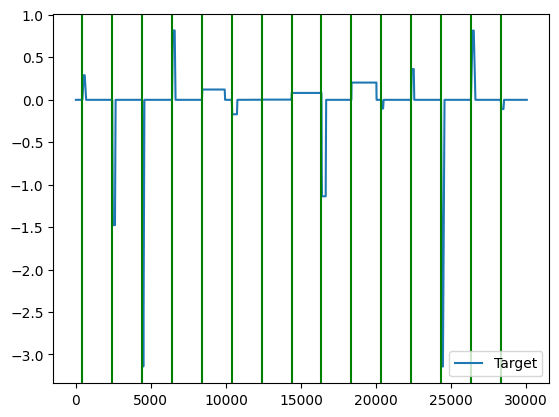

In [50]:
lower_bound = 0
upper_bound = -1

plt.plot(sensor_data_np[lower_bound:upper_bound, -1], label="Target")
for i in start_indexes:
    plt.axvline(i, color="g")

plt.legend()

In [51]:
def determine_movement_ends(joint_vels: np.ndarray, start_indexes: list, threshold=1e-3, window=5):
    end_timestamps = []
    
    # Combine into a single speed since every joint finishes moving at the same time
    speed = np.linalg.norm(joint_vels, axis=1)
    
    for i in start_indexes:
        # Only look at data occurring after the start of this specific movement
        post_start_speed = speed[i:]
        
        # Find where speed drops below the threshold
        under_threshold = post_start_speed < threshold
        
        # To avoid mid-motion zero-crossings, ensure speed stays low for 'window' frames
        # We use a logical convolution to find a sequence of 'True' values
        is_settled = np.convolve(under_threshold, np.ones(window), mode='valid') == window
        
        # Find the first index where the 'settled' condition is met
        settled_indices = np.where(is_settled)[0]
        
        if settled_indices.size > 0:
            # We add 'ts' to get the global index, and 'window' isn't strictly 
            # necessary but helps point to the actual start of the stillness
            end_timestamps.append(i + settled_indices[0])
        else:
            # Fallback to end of array if no stop is detected
            end_timestamps.append(len(joint_vels) - 1)
            
    return end_timestamps

[431, 2424, 4415, 6407, 8400, 10390, 12382, 14374, 16368, 18361, 20353, 22345, 24336, 26329, 28320]
[677, 2641, 4560, 6636, 9938, 10757, 16674, 16674, 16674, 20035, 20505, 22547, 24562, 26622, 28524]


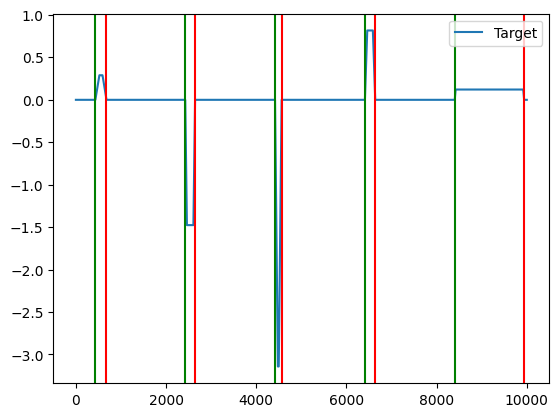

In [52]:
lower_bound = 0
upper_bound = 10000

joint_vels = sensor_data_np[:, -6:]
joint_vels = joint_vels.astype(np.float64)

end_indexes = determine_movement_ends(joint_vels, start_indexes)

print(start_indexes)
print(end_indexes)

plt.plot(sensor_data_np[lower_bound:upper_bound, -1], label="Target")
for i, _ in enumerate(start_indexes):
    if lower_bound < start_indexes[i] < upper_bound:
        plt.axvline(start_indexes[i], color="g")
    if lower_bound < end_indexes[i] < upper_bound:
        plt.axvline(end_indexes[i], color="r")


plt.legend()

# Declaring data needed for training

We want to train a model to predict the time it takes to do a certain movement. Thus we now need to extract, the time a movement takes, and the start and end position

In [53]:
# Extract time
# This is easy as it is just the difference between the start and end timesteps of movements
start_positions = []
end_positions = []
movement_time = []

joint_positions = sensor_data_np[:, -12:-6]

for i, _ in enumerate(start_indexes):
    # Determine time taken
    time_taken = sensor_data_np[end_indexes[i], 2] - sensor_data_np[start_indexes[i], 2]
    movement_time.append(time_taken.total_seconds()) # save time taken in seconds

    # Extract start and end pos
    start_pos = joint_positions[start_indexes[i], :]
    start_positions.append(start_pos)

    end_pos = joint_positions[end_indexes[i], :]
    end_positions.append(end_pos)


print(f"{movement_time=}\n")
print(f"{start_positions=}\n")
print(f"{end_positions=}\n")

movement_time=[12.344599, 10.870025, 7.273785, 11.496336, 77.30096, 18.416548, 215.377237, 115.374988, 15.36452, 84.026351, 7.628875, 10.106963, 11.337089, 14.740743, 10.255264]

start_positions=[array([1.3019280147000384e-06, -1.570002385012374, 1.5699981579699005,
       -1.5700015653641934, -1.5699986279975142, 1.3768857308362917e-06],
      dtype=object), array([-19.589243234885735, -17.538464612792122, -11.278324315811732,
       5.3779976529511435, -19.43914785633235, 2.297210231230316],
      dtype=object), array([4.978061494544372, -6.265178731421305, 3.3754145612445576,
       2.300404557894435, 1.7679631627278076, -11.065158936322312],
      dtype=object), array([-3.350485515193317, -0.7746207591538126, -4.932323281687005,
       0.5498418367322703, -3.7186193082516765, -24.059873405915916],
      dtype=object), array([-24.491649972444424, -9.97849714925301, -11.690545399957397,
       -0.5521718596124549, -24.0517479859623, -16.834757715456146],
      dtype=object), array([0

In [54]:
start_positions[0]

array([1.3019280147000384e-06, -1.570002385012374, 1.5699981579699005,
       -1.5700015653641934, -1.5699986279975142, 1.3768857308362917e-06],
      dtype=object)

In [55]:
end_positions[0]

array([-19.589244719182247, -17.538457817971878, -11.278325832773644,
       5.377998035834856, -19.439139269287235, 2.2972116961366527],
      dtype=object)

# Plot of correlation between the max distance a joint has to move and the time the movement takes.

In [56]:
max_position_diff = []

for i, _ in enumerate(start_positions):
    max_position_diff.append(np.max(np.abs(end_positions[i] - start_positions[i])))

max_position_diff

[19.589246021110263,
 24.567304947611852,
 12.994712897033665,
 21.14116885373777,
 37.74936264222374,
 38.03649457760818,
 37.93808140616521,
 43.4247390452374,
 44.06555353132393,
 28.320445829381697,
 19.046018696512135,
 27.38804823915408,
 19.91597648192287,
 29.67313403894286,
 17.890343624904013]

Text(0.5, 0, 'Max angle difference (rad)')

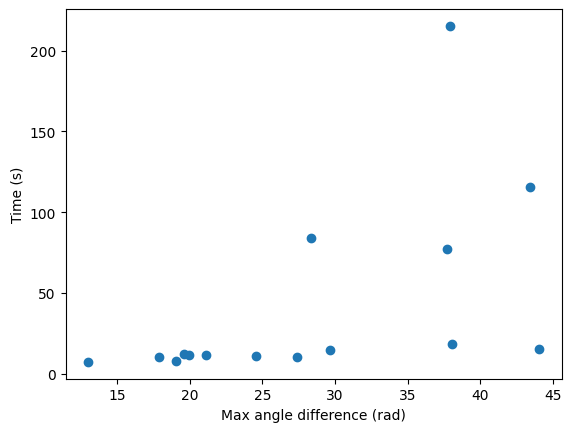

In [57]:
plt.scatter(max_position_diff, movement_time)
plt.ylabel("Time (s)")
plt.xlabel("Max angle difference (rad)")

## Proposing model

Since it does not look like a nice linear correlation, we will throw a neural network at it. In this case, the architecture will be based on the MLP.

In [58]:
A = np.vander(max_position_diff, 2)
b = np.array(movement_time)

x = np.linalg.pinv(A) @ b

x

array([  3.21311681, -48.87917523])

We can now use the found coefficients $x_0$ and $x_1$ to make a model:

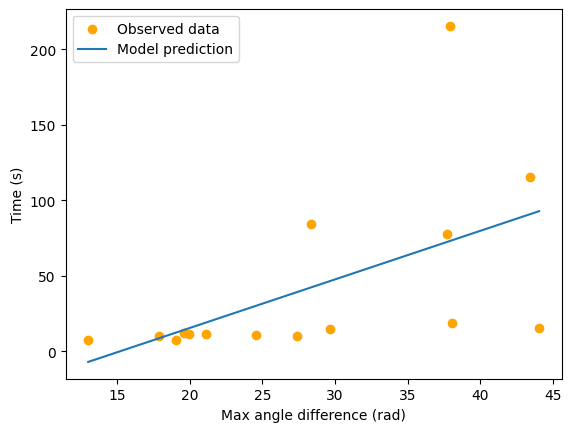

In [59]:
angle_space = np.linspace(np.min(max_position_diff), np.max(max_position_diff), 100)

# Feed through model
def linear_reg_model(n: np.ndarray, x: np.ndarray):
    n_vander = np.vander(n, 2)
    return n_vander @ x

time_spent_prediction = linear_reg_model(angle_space, x)

plt.scatter(max_position_diff, movement_time, color="orange", label="Observed data")
plt.plot(angle_space, time_spent_prediction, label="Model prediction")
plt.ylabel("Time (s)")
plt.xlabel("Max angle difference (rad)")
plt.legend()